In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from pathlib import Path
import sqlite3
from scipy.optimize import least_squares
import surfinBH
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
import lal
from tqdm.auto import tqdm
from mpl_toolkits.mplot3d import Axes3D
import precession as prececc
lal.swig_redirect_standard_output_error(True)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


True

In [2]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


In [3]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)
    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

### 0PN reduced circular model

In this cell we compute the Newtonian, or 0PN, conservative mass and angular momentum used for the entropy calculation. The implementation uses the same radial Blanchet convention adopted in the higher-order PN models, with

$$
\Gamma = \frac{Gm}{r}.
$$

Since the precession output provides the dimensionless separation

$$
a_{\rm prec} = \frac{r}{m},
$$

we use

$$
\Gamma = \frac{G}{a_{\rm prec}}.
$$

At 0PN order the binding energy is

$$
E_{\rm bind}^{0{\rm PN}}
=

-\frac{\mu\Gamma}{2},
$$

where

$$
m=m_1+m_2,
\qquad
\mu=\frac{m_1m_2}{m},
\qquad
\nu=\frac{\mu}{m}.
$$

The total mass entering the Kerr entropy is therefore

$$
M_{\rm tot}
=

m+\frac{E_{\rm bind}^{0{\rm PN}}}{c^2}.
$$

The Newtonian orbital angular momentum is

$$
L_{\rm orb}^{0{\rm PN}}
=

\frac{G\mu m}{\sqrt{\Gamma}}.
$$

The total angular momentum is constructed by adding the physical spin contribution,

$$
\mathbf J
=

\mathbf L_{\rm orb}^{0{\rm PN}}
+
\frac{\mathbf S_1+\mathbf S_2}{c}.
$$

The scalar angular momentum used in the Kerr entropy is

$$
J_{\rm tot}
=

|\mathbf J|.
$$

Thus, this function represents the 0PN truncation of the reduced circular Blanchet-style model. It contains the Newtonian orbital energy and angular momentum, while spin effects enter only through the spin contribution to the total angular momentum.


In [4]:
def get_0PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
   
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")
    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless spins must satisfy |chi_i| <= 1.")

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m
    q_prec = m2 / m1

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)
    gamma_Blanchet = Gamma / c**2

    E_bind_0PN = -0.5 * mu * Gamma
    E_bind = E_bind_0PN

    E_tot = m + E_bind / c**2

    L_orb_0PN = G * mu * m / sqrt_Gamma
    L_orb = L_orb_0PN

    L_vec = np.stack(
        [
            np.zeros_like(L_orb),
            np.zeros_like(L_orb),
            L_orb
        ],
        axis=-1
    )

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1_vec = np.stack(
        [
            S1_mag * np.sin(th1),
            np.zeros_like(th1),
            S1_mag * np.cos(th1)
        ],
        axis=-1
    )

    S2_vec = np.stack(
        [
            S2_mag * np.sin(th2) * np.cos(dphi),
            S2_mag * np.sin(th2) * np.sin(dphi),
            S2_mag * np.cos(th2)
        ],
        axis=-1
    )

    S_tot_vec = S1_vec + S2_vec

    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        "q_prec": q_prec,

        "Gamma": Gamma,
        "gamma_Blanchet": gamma_Blanchet,

        "nu": nu,
        "mu": mu,
        "m": m,
        "m1": m1,
        "m2": m2,

        "E_bind": E_bind,
        "E_tot": E_tot,
        "E_bind_0PN": E_bind_0PN,

        "L_orb": L_orb,
        "L_orb_0PN": L_orb_0PN,
        "L_vec": L_vec,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "J_vec": J_vec,
        "J_tot": J_tot
    }

### 1PN reduced circular model

In this cell we compute the 1PN conservative mass and angular momentum used for the entropy calculation. The implementation uses the same radial Blanchet convention adopted in the 2PN model, with

$$
\Gamma = \frac{Gm}{r}.
$$

Since the precession output provides the dimensionless separation

$$
a_{\rm prec} = \frac{r}{m},
$$

we use

$$
\Gamma = \frac{G}{a_{\rm prec}}.
$$

The binding energy is truncated at 1PN order:

$$
E_{\rm bind}
=

-\frac{\mu\Gamma}{2}
+
\frac{\mu\Gamma^2}{8c^2}
\left(
7-\nu
\right),
$$

where

$$
m=m_1+m_2,
\qquad
\mu=\frac{m_1m_2}{m},
\qquad
\nu=\frac{\mu}{m}.
$$

The total mass entering the Kerr entropy is then

$$
M_{\rm tot}
=

m+\frac{E_{\rm bind}}{c^2}.
$$

The orbital angular momentum is also truncated at 1PN order:

$$
L_{\rm orb}
=

\frac{G\mu m}{\sqrt{\Gamma}}
+
\frac{2G\mu m\sqrt{\Gamma}}{c^2}.
$$

At this order no spin-orbit or spin-spin PN corrections are included, since the leading spin-orbit term enters at 1.5PN and the leading spin-spin sector enters at 2PN. The total angular momentum is therefore constructed as

$$
\mathbf J
=

\mathbf L_{\rm orb}
+
\frac{\mathbf S_1+\mathbf S_2}{c}.
$$

The scalar angular momentum used in the Kerr entropy is

$$
J_{\rm tot}
=

|\mathbf J|.
$$

Thus, this function represents the 1PN truncation of the same reduced circular Blanchet-style model used at 2PN.


In [5]:
def get_1PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")
    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless spins must satisfy |chi_i| <= 1.")

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)
    gamma_Blanchet = Gamma / c**2

    E_bind_0PN = -0.5 * mu * Gamma

    E_bind_1PN = (
        mu
        * Gamma**2
        * (7.0 - nu)
        / 8.0
        / c**2
    )

    E_bind = (
        E_bind_0PN
        +
        E_bind_1PN
    )

    E_tot = m + E_bind / c**2

    L_orb_0PN = (
        G
        * mu
        * m
        / sqrt_Gamma
    )

    L_orb_1PN = (
        2.0
        * G
        * mu
        * m
        * sqrt_Gamma
        / c**2
    )

    L_orb = (
        L_orb_0PN
        +
        L_orb_1PN
    )

    L_vec = np.stack(
        [
            np.zeros_like(L_orb),
            np.zeros_like(L_orb),
            L_orb
        ],
        axis=-1
    )

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1_vec = np.stack(
        [
            S1_mag * np.sin(th1),
            np.zeros_like(th1),
            S1_mag * np.cos(th1)
        ],
        axis=-1
    )

    S2_vec = np.stack(
        [
            S2_mag * np.sin(th2) * np.cos(dphi),
            S2_mag * np.sin(th2) * np.sin(dphi),
            S2_mag * np.cos(th2)
        ],
        axis=-1
    )

    S_tot_vec = S1_vec + S2_vec

    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        "Gamma": Gamma,
        "gamma_Blanchet": gamma_Blanchet,

        "nu": nu,
        "mu": mu,
        "m": m,
        "m1": m1,
        "m2": m2,

        "E_bind": E_bind,
        "E_tot": E_tot,

        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN": E_bind_1PN,

        "L_orb": L_orb,
        "L_orb_0PN": L_orb_0PN,
        "L_orb_1PN": L_orb_1PN,

        "L_vec": L_vec,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "J_vec": J_vec,
        "J_tot": J_tot
    }

### 2PN reduced circular model

In this notebook we use the final 2PN function as a reduced circular-orbit model written in the radial Blanchet convention. The PN variable is

$$
\Gamma = \frac{Gm}{r},
$$

and, since the precession output uses the dimensionless separation

$$
a_{\rm prec} = \frac{r}{m},
$$

we use

$$
\Gamma = \frac{G}{a_{\rm prec}}.
$$

The function computes the total mass as

$$
M_{\rm tot}
=

m+\frac{E_{\rm bind}}{c^2},
$$

where the binding energy contains the non-spinning point-particle terms up to 2PN order, the leading spin-orbit term at 1.5PN, and the leading spin-spin sector at 2PN, including both mutual spin-spin and Kerr self-spin/quadrupole terms.

The total angular momentum is constructed as

$$
\mathbf J
=

\mathbf L_{\rm NS}
+
\mathbf L_{\rm SO}
+
\mathbf L_{\rm SS}
+
\frac{\mathbf S_1+\mathbf S_2}{c}.
$$

Here, $\mathbf L_{\rm NS}$ includes the non-spinning orbital angular momentum up to 2PN, $\mathbf L_{\rm SO}$ is the leading spin-orbit correction, and $\mathbf L_{\rm SS}$ is a reduced circular spin-spin correction added along the orbital angular-momentum direction $\boldsymbol{\ell}$.

The scalar angular momentum used in the Kerr entropy is

$$
J_{\rm tot}
=

\sqrt{
J_n^2
+
J_\lambda^2
+
J_\ell^2
}.
$$

Therefore, the entropy curve is computed from

$$
S_{\rm Kerr}
=

S_{\rm Kerr}
\left(
M_{\rm tot},
J_{\rm tot}
\right).
$$

This implementation should be interpreted as a reduced circular 2PN model, not as the full generic precessing Noetherian angular momentum. It is nevertheless internally consistent for the present entropy analysis, provided that all quantities are evaluated in the same radial Blanchet convention.


In [6]:
def get_2PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")
    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless spins must satisfy |chi_i| <= 1.")

    # Kerr black-hole quadrupole coefficients
    CQ1 = 1.0
    CQ2 = 1.0

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")
    
    # ============================================================
    # Mass parameters
    # ============================================================

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    # ============================================================
    # Blanchet radial PN variable
    # ============================================================

    if separation_is_dimensionless:
        # a_prec = r / m  ->  Gamma = G m / r = G / a_prec
        Gamma = G / a_prec
    else:
        # a_prec = r      ->  Gamma = G m / r
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)
    gamma_Blanchet = Gamma / c**2

    # ============================================================
    # Spin vectors in the orbital triad (n, lambda, ell)
    # ============================================================

    # Blanchet-style spin variable:
    # physical spin angular momentum contributes as S_i / c to J.
    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    # By convention phi1 = 0
    S1n = S1_mag * np.sin(th1)
    S1lam = np.zeros_like(th1)
    S1L = S1_mag * np.cos(th1)

    # phi2 = dphi
    S2n = S2_mag * np.sin(th2) * np.cos(dphi)
    S2lam = S2_mag * np.sin(th2) * np.sin(dphi)
    S2L = S2_mag * np.cos(th2)

    S1_vec = np.stack([S1n, S1lam, S1L], axis=-1)
    S2_vec = np.stack([S2n, S2lam, S2L], axis=-1)

    S_tot_vec = S1_vec + S2_vec

    S1S2 = np.sum(S1_vec * S2_vec, axis=-1)
    S1sq = np.sum(S1_vec * S1_vec, axis=-1)
    S2sq = np.sum(S2_vec * S2_vec, axis=-1)

    # ============================================================
    # Spin combinations
    # ============================================================

    bracket_SO_L = (
        S1L * (4.0 * m1 * m2 + 3.0 * m2**2)
        +
        S2L * (3.0 * m1**2 + 4.0 * m1 * m2)
    )

    bracket_Mutual_SS = (
        -S1S2
        +
        3.0 * S1L * S2L
    )

    bracket_Self_SS_1 = (
        -S1sq
        +
        3.0 * S1L**2
    )

    bracket_Self_SS_2 = (
        -S2sq
        +
        3.0 * S2L**2
    )

    bracket_Self_SS_total = (
        CQ1 * (m2 / m1) * bracket_Self_SS_1
        +
        CQ2 * (m1 / m2) * bracket_Self_SS_2
    )

    bracket_SS_total = (
        bracket_Mutual_SS
        +
        0.5 * bracket_Self_SS_total
    )

    # ============================================================
    # Binding energy in Blanchet radial convention
    # ============================================================

    E_bind_0PN = (
        -0.5
        * mu
        * Gamma
    )

    E_bind_1PN = (
        mu
        * Gamma**2
        * (7.0 - nu)
        / 8.0
        / c**2
    )

    E_bind_SO_15PN = (
        -mu
        * Gamma**2.5
        / (3.0 * G * m**2 * m1 * m2)
        * bracket_SO_L
        / c**3
    )

    E_bind_2PN_NS = (
        mu
        * Gamma**3
        * (7.0 - 49.0 * nu - nu**2)
        / 16.0
        / c**4
    )

    E_bind_SS_mutual_2PN = (
        -Gamma**3
        / (2.0 * G**2 * m**3)
        * bracket_Mutual_SS
        / c**4
    )

    E_bind_SS_self_2PN = (
        -Gamma**3
        / (4.0 * G**2 * m**3)
        * bracket_Self_SS_total
        / c**4
    )

    E_bind_SS_2PN = (
        E_bind_SS_mutual_2PN
        +
        E_bind_SS_self_2PN
    )

    E_bind = (
        E_bind_0PN
        +
        E_bind_1PN
        +
        E_bind_SO_15PN
        +
        E_bind_2PN_NS
        +
        E_bind_SS_2PN
    )

    # Convert binding energy into mass contribution
    E_tot = m + E_bind / c**2

    # ============================================================
    # Non-spinning orbital angular momentum
    # ============================================================

    L_NS_0PN = (
        G
        * mu
        * m
        / sqrt_Gamma
    )

    L_NS_1PN = (
        2.0
        * G
        * mu
        * m
        * sqrt_Gamma
        / c**2
    )

    L_NS_2PN = (
        G
        * mu
        * m
        * Gamma**1.5
        * (5.0 - 9.0 * nu)
        / 2.0
        / c**4
    )

    L_NS = (
        L_NS_0PN
        +
        L_NS_1PN
        +
        L_NS_2PN
    )

    # ============================================================
    # Leading spin-orbit correction to orbital angular momentum
    # ============================================================

    L_SO_L_15PN = (
        -5.0
        * Gamma
        / (6.0 * m**2)
        * bracket_SO_L
        / c**3
    )

    L_SO_n_15PN = (
        Gamma
        / (2.0 * m**2)
        * (
            m2**2 * S1n
            +
            m1**2 * S2n
        )
        / c**3
    )

    L_SO_lam_15PN = (
        -Gamma
        / m**2
        * (
            m2 * (2.0 * m1 + m2) * S1lam
            +
            m1 * (m1 + 2.0 * m2) * S2lam
        )
        / c**3
    )

    # ============================================================
    # Leading spin-spin correction to orbital angular momentum
    # ============================================================
    # Reduced circular-orbit spin-spin correction.
    # It is added only along ell.
    #
    # This is inferred consistently from the leading spin-spin
    # binding energy through the circular relation dE = Omega dJ.
    # It is therefore a reduced circular model, not the full generic
    # precessing Noetherian L_SS.

    L_SS_L_2PN = (
        -Gamma**1.5
        / (G * m**2)
        * bracket_SS_total
        / c**4
    )

    L_SS_n_2PN = np.zeros_like(Gamma)
    L_SS_lam_2PN = np.zeros_like(Gamma)

    # ============================================================
    # Total orbital angular momentum vector
    # ============================================================

    L_n = (
        L_SO_n_15PN
        +
        L_SS_n_2PN
    )

    L_lam = (
        L_SO_lam_15PN
        +
        L_SS_lam_2PN
    )

    L_ell = (
        L_NS
        +
        L_SO_L_15PN
        +
        L_SS_L_2PN
    )

    L_vec = np.stack([L_n, L_lam, L_ell], axis=-1)

    # ============================================================
    # Total angular momentum
    # ============================================================

    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        # PN variables
        "Gamma": Gamma,
        "gamma_Blanchet": gamma_Blanchet,

        # Mass parameters
        "nu": nu,
        "mu": mu,
        "m": m,
        "m1": m1,
        "m2": m2,

        # Quadrupole coefficients
        "CQ1": CQ1,
        "CQ2": CQ2,

        # Energy
        "E_bind": E_bind,
        "E_tot": E_tot,

        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN": E_bind_1PN,
        "E_bind_SO_15PN": E_bind_SO_15PN,
        "E_bind_2PN_NS": E_bind_2PN_NS,

        "E_bind_SS_2PN": E_bind_SS_2PN,
        "E_bind_SS_mutual_2PN": E_bind_SS_mutual_2PN,
        "E_bind_SS_self_2PN": E_bind_SS_self_2PN,

        # Angular momentum
        "L_vec": L_vec,
        "L_n": L_n,
        "L_lam": L_lam,
        "L_ell": L_ell,

        "L_NS": L_NS,
        "L_NS_0PN": L_NS_0PN,
        "L_NS_1PN": L_NS_1PN,
        "L_NS_2PN": L_NS_2PN,

        "L_SO_n_15PN": L_SO_n_15PN,
        "L_SO_lam_15PN": L_SO_lam_15PN,
        "L_SO_L_15PN": L_SO_L_15PN,

        "L_SS_n_2PN": L_SS_n_2PN,
        "L_SS_lam_2PN": L_SS_lam_2PN,
        "L_SS_L_2PN": L_SS_L_2PN,

        # Spins
        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "S1n": S1n,
        "S1lam": S1lam,
        "S1L": S1L,

        "S2n": S2n,
        "S2lam": S2lam,
        "S2L": S2L,

        "S1S2": S1S2,
        "S1sq": S1sq,
        "S2sq": S2sq,

        # Brackets
        "bracket_SO_L": bracket_SO_L,
        "bracket_Mutual_SS": bracket_Mutual_SS,
        "bracket_Self_SS_1": bracket_Self_SS_1,
        "bracket_Self_SS_2": bracket_Self_SS_2,
        "bracket_Self_SS_total": bracket_Self_SS_total,
        "bracket_SS_total": bracket_SS_total,

        # Total angular momentum
        "J_vec": J_vec,
        "J_tot": J_tot,
    }

### NR surrogate estimate of the merger separation

In this cell we estimate the effective merger separation from the NR surrogate waveform. First, we convert a reference separation \(a_{\rm ref}\) into a gravitational-wave reference frequency.

For a circular orbit, the Newtonian orbital frequency is

$$
\Omega_{\mathrm{orb}}
=
a_{\rm ref}^{-3/2}
$$

Since the dominant \((2,2)\) gravitational-wave mode has angular frequency

$$
\omega_{22}
\simeq
2\Omega_{\mathrm{orb}}
$$

the corresponding gravitational-wave frequency is

$$
f_{\mathrm{gw}}
=
\frac{\omega_{22}}{2\pi}
=
\frac{\Omega_{\mathrm{orb}}}{\pi}
$$

Therefore,

$$
f_{\mathrm{gw}}
=
\frac{a_{\rm ref}^{-3/2}}{\pi}
$$

The function `get_merger_separation_NR` generates the precessing surrogate waveform using the input mass ratio, spin vectors, and reference frequency. From the dominant mode \(h_{22}\), the merger time is identified as the time at which the amplitude reaches its maximum,

$$
|h_{22}(t)|
$$

The instantaneous gravitational-wave phase is computed from

$$
\phi_{22}(t)
=
\arg h_{22}(t)
$$

and the corresponding instantaneous \((2,2)\)-mode angular frequency is

$$
\omega_{22}(t)
=
\left|
\frac{d\phi_{22}}{dt}
\right|
$$

The instantaneous orbital frequency is then estimated as

$$
\omega_{\mathrm{orb}}(t)
=
\frac{\omega_{22}(t)}{2}
$$

Using the Newtonian circular-orbit relation, the instantaneous effective separation is

$$
a_{\mathrm{inst}}(t)
=
\omega_{\mathrm{orb}}(t)^{-2/3}
$$

Finally, the merger separation is defined as the median value of \(a_{\mathrm{inst}}(t)\) in a small time window around the peak of \(|h_{22}|\):

$$
a_{\mathrm{merger}}^{\mathrm{NR}}
=
\mathrm{median}
\left[
a_{\mathrm{inst}}(t)
\right]_{\mathrm{peak\ window}}
$$

This gives an effective NR-based estimate of the merger separation, which can be compared with the position of the maximum of the PN entropy curve.

In [7]:
def get_gw_frequency_from_separation(a_ref):

    a_ref = float(a_ref)
    omega_orb = a_ref**(-1.5)
    f_gw = omega_orb / np.pi

    return f_gw
def get_merger_separation_NR(
    q_surr,
    chi1_0_vec,
    chi2_0_vec,
    f_ref,
    f_low=0.0,
    dt=0.1,
    peak_window=5
):
    
    q_surr = float(q_surr)
    f_ref = float(f_ref)
    f_low = float(f_low)

    chi1_0_vec = np.asarray(chi1_0_vec, dtype=float)
    chi2_0_vec = np.asarray(chi2_0_vec, dtype=float)

    if q_surr < 1.0:
        raise ValueError("q_surr must satisfy q_surr >= 1.")
    if not np.isfinite(f_ref) or f_ref <= 0.0:
        raise ValueError("f_ref must be finite and positive.")
    if not np.isfinite(f_low) or f_low < 0.0:
        raise ValueError("f_low must be finite and non-negative.")

    if f_ref < f_low:
        print("WARNING: f_ref < f_low.")
        f_low = 0.0

    t, h, _ = sur_wave_precessing(
        q_surr,
        chi1_0_vec,
        chi2_0_vec,
        dt=dt,
        f_low=f_low,
        f_ref=f_ref
    )

    h22 = h[(2, 2)]
    amp22 = np.abs(h22)
    idx_peak = int(np.nanargmax(amp22))
    phase22 = np.unwrap(np.angle(h22))
    omega22 = np.abs(np.gradient(phase22, t))
    omega_orb = omega22 / 2.0
    a_inst = np.maximum(omega_orb, 1.0e-12)**(-2.0 / 3.0)
    i_min = max(0, idx_peak - peak_window)
    i_max = min(len(t), idx_peak + peak_window + 1)
    a_merger = np.nanmedian(a_inst[i_min:i_max])

    return a_merger, t, a_inst

In [8]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

,spin_geometry,category,priority,theta1_deg,theta2_deg,dphi_deg
0,nearly_aligned,aligned,baseline,0.057296,0.057296,0.0
1,nearly_antialigned,antialigned,baseline,179.942704,179.942704,0.0
2,primary_aligned_secondary_antialigned,mixed_aligned,baseline,0.057296,179.942704,0.0
3,primary_antialigned_secondary_aligned,mixed_aligned,baseline,179.942704,0.057296,0.0
4,counter_tilted_opposite_azimuth,counter_tilted,exotic,45.000000,135.000000,180.0
5,counter_tilted_same_plane,counter_tilted,exotic,45.000000,135.000000,0.0
6,in_plane_oblique_135,in_plane,exotic,90.000000,90.000000,135.0
7,in_plane_oblique_45,in_plane,exotic,90.000000,90.000000,45.0
8,random_like_1,random_like,exotic,23.000000,97.000000,37.0
9,random_like_2,random_like,exotic,112.000000,41.000000,128.0



Physical parameters:
config_id      = q0.30_chi10.40_chi20.20_primary_tilted_secondary_aligned
q_prec         = 0.3
m1             = 0.7692307692307692
m2             = 0.23076923076923075
chi1           = 0.4
chi2           = 0.2
theta1_0       = 60.000 deg
theta2_0       = 0.057 deg
dphi_0         = 0.000 deg
spin_geometry  = primary_tilted_secondary_aligned
category       = single_tilt
priority       = high


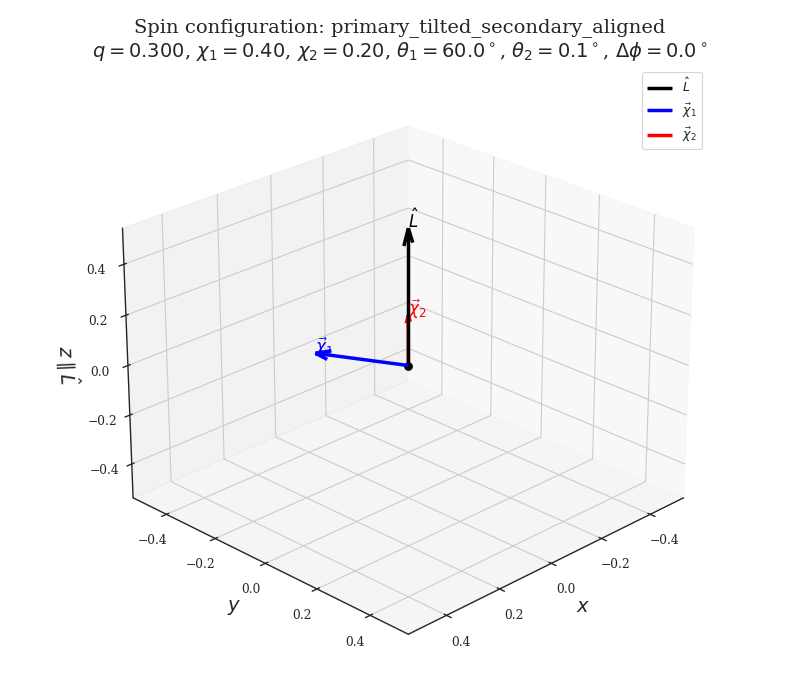

In [216]:
campaign_db_path = Path("/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/""bbh_precession_campaign/bbh_lowq_precession_campaign.sqlite")
conn = sqlite3.connect(campaign_db_path)
catalog_df = pd.read_sql_query("SELECT * FROM catalog",conn)
display(catalog_df[["spin_geometry", "category", "priority", "theta1_deg", "theta2_deg", "dphi_deg"]].drop_duplicates().sort_values(["priority", "category", "spin_geometry"]).reset_index(drop=True))

target_q = 0.3
target_chi1 = 0.40
target_chi2 = 0.20
target_spin_geometry = "primary_tilted_secondary_aligned"

mask = ((catalog_df["status"] == "simulated")& np.isclose(catalog_df["q"], target_q)& np.isclose(catalog_df["chi1"], target_chi1)& np.isclose(catalog_df["chi2"], target_chi2)& (catalog_df["spin_geometry"] == target_spin_geometry))
matching_configs = catalog_df[mask].copy().reset_index(drop=True)

if len(matching_configs) == 0:
    conn.close()
    raise ValueError("No configuration found")

selected_config = matching_configs.iloc[0]
config_id = selected_config["config_id"]
df_evol = pd.read_sql_query("SELECT * FROM evolutions WHERE config_id = ?",conn,params=(config_id,))
conn.close()

if len(df_evol) == 0:
    raise ValueError(f"No evolution found")


q_prec = float(selected_config["q"])

m1 = float(selected_config["m1"])
m2 = float(selected_config["m2"])
chi1 = float(selected_config["chi1"])
chi2 = float(selected_config["chi2"])
theta1_0 = float(selected_config["theta1_rad"])
theta2_0 = float(selected_config["theta2_rad"])
dphi_0 = float(selected_config["dphi_rad"])
theta1_0_deg = float(selected_config["theta1_deg"])
theta2_0_deg = float(selected_config["theta2_deg"])
dphi_0_deg = float(selected_config["dphi_deg"])
spin_geometry = selected_config["spin_geometry"]
category = selected_config["category"]
priority = selected_config["priority"]

print()
print("Physical parameters:")
print(f"config_id      = {config_id}")
print(f"q_prec         = {q_prec}")
print(f"m1             = {m1}")
print(f"m2             = {m2}")
print(f"chi1           = {chi1}")
print(f"chi2           = {chi2}")
print(f"theta1_0       = {theta1_0_deg:.3f} deg")
print(f"theta2_0       = {theta2_0_deg:.3f} deg")
print(f"dphi_0         = {dphi_0_deg:.3f} deg")
print(f"spin_geometry  = {spin_geometry}")
print(f"category       = {category}")
print(f"priority       = {priority}")



def get_column(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return df[name].to_numpy(dtype=float), name
    raise KeyError(
        "None of these columns were found")

a_prec, a_col = get_column(df_evol,["a", "separation", "r"])
th1, th1_col = get_column(df_evol,["theta1", "th1", "theta_1", "theta1_0", "theta1_0_rad"])
th2, th2_col = get_column(df_evol,["theta2", "th2", "theta_2", "theta2_0", "theta2_0_rad"])
dphi, dphi_col = get_column(df_evol,["deltaphi", "dphi", "delta_phi", "DeltaPhi", "dphi_0", "dphi_0_rad"])



# visualization

def spin_cartesian(chi, theta, phi):
    x = chi * np.sin(theta) * np.cos(phi)
    y = chi * np.sin(theta) * np.sin(phi)
    z = chi * np.cos(theta)

    return np.array([x, y, z], dtype=float)

def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)

    x_mid = np.mean(x_limits)
    y_mid = np.mean(y_limits)
    z_mid = np.mean(z_limits)

    ax.set_xlim3d([x_mid - max_range / 2, x_mid + max_range / 2])
    ax.set_ylim3d([y_mid - max_range / 2, y_mid + max_range / 2])
    ax.set_zlim3d([z_mid - max_range / 2, z_mid + max_range / 2])

phi1_0 = 0.0
phi2_0 = dphi_0
chi1_vec = spin_cartesian(chi1, theta1_0, phi1_0)
chi2_vec = spin_cartesian(chi2, theta2_0, phi2_0)
Lhat_vec = np.array([0.0, 0.0, 1.0])
max_val = max(chi1, chi2)
axis_limit = 1.35 * max_val

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(0, 0, 0, color="black", s=30)
ax.quiver(
    0, 0, 0,
    0, 0, axis_limit,
    color="black",
    linewidth=2.5,
    arrow_length_ratio=0.12,
    label=r"$\hat{L}$"
)
ax.quiver(
    0, 0, 0,
    chi1_vec[0], chi1_vec[1], chi1_vec[2],
    color="blue",
    linewidth=2.5,
    arrow_length_ratio=0.15,
    label=r"$\vec{\chi}_1$"
)
ax.quiver(
    0, 0, 0,
    chi2_vec[0], chi2_vec[1], chi2_vec[2],
    color="red",
    linewidth=2.5,
    arrow_length_ratio=0.15,
    label=r"$\vec{\chi}_2$"
)

ax.text(0, 0, axis_limit, r"$\hat{L}$", color="black")
ax.text(chi1_vec[0], chi1_vec[1], chi1_vec[2], r"$\vec{\chi}_1$", color="blue")
ax.text(chi2_vec[0], chi2_vec[1], chi2_vec[2], r"$\vec{\chi}_2$", color="red")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z \parallel \hat{L}$")
ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)
ax.set_zlim(-axis_limit, axis_limit)
set_axes_equal(ax)
ax.set_title(
    rf"Spin configuration: {spin_geometry}"
    "\n"
    rf"$q={q_prec:.3f}$, "
    rf"$\chi_1={chi1:.2f}$, "
    rf"$\chi_2={chi2:.2f}$, "
    rf"$\theta_1={theta1_0_deg:.1f}^\circ$, "
    rf"$\theta_2={theta2_0_deg:.1f}^\circ$, "
    rf"$\Delta\phi={dphi_0_deg:.1f}^\circ$"
)
ax.legend()
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

In [217]:
def interpolate_at_separation(a_array, y_array, a_ref):
    a_array = np.asarray(a_array, dtype=float)
    y_array = np.asarray(y_array, dtype=float)
    valid = np.isfinite(a_array) & np.isfinite(y_array)
    a_valid = a_array[valid]
    y_valid = y_array[valid]
    sort_idx = np.argsort(a_valid)
    a_sorted = a_valid[sort_idx]
    y_sorted = y_valid[sort_idx]

    if a_ref < a_sorted[0] or a_ref > a_sorted[-1]:
        raise ValueError(
            f"a_ref = {a_ref:.8f} is outside the available precession range "
            f"[{a_sorted[0]:.8f}, {a_sorted[-1]:.8f}]."
        )

    return np.interp(a_ref, a_sorted, y_sorted)

def build_spin_vectors_from_angles(chi1, chi2, theta1, theta2, dphi):
    phi1 = 0.0
    phi2 = phi1 + dphi
    chi1_vec = np.array([
        chi1 * np.sin(theta1) * np.cos(phi1),
        chi1 * np.sin(theta1) * np.sin(phi1),
        chi1 * np.cos(theta1)
    ])
    chi2_vec = np.array([
        chi2 * np.sin(theta2) * np.cos(phi2),
        chi2 * np.sin(theta2) * np.sin(phi2),
        chi2 * np.cos(theta2)
    ])

    return chi1_vec, chi2_vec

def extract_merger_from_waveform(t, h, peak_window=5):
    h22 = h[(2, 2)]
    amp22 = np.abs(h22)
    idx_peak = int(np.nanargmax(amp22))
    phase22 = np.unwrap(np.angle(h22))
    omega22 = np.abs(np.gradient(phase22, t))
    omega_orb = omega22 / 2.0
    a_inst = np.maximum(omega_orb, 1.0e-12)**(-2.0 / 3.0)
    i_min = max(0, idx_peak - peak_window)
    i_max = min(len(t), idx_peak + peak_window + 1)
    a_merger = np.nanmedian(a_inst[i_min:i_max])

    return a_merger, a_inst, idx_peak

def get_merger_separation_NR_adaptive_fref(
    q_surr,
    chi1,
    chi2,
    a_prec,
    th1,
    th2,
    dphi,
    omega_ref_start=0.0195,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5
):
    q_surr = float(q_surr)

    if q_surr < 1.0:
        raise ValueError("q_surr must satisfy q_surr >= 1.")

    dphi_unwrapped = np.unwrap(dphi)

    last_error = None

    for attempt in range(max_attempts):

        omega_ref = omega_ref_start * omega_ref_factor**attempt
        f_ref = omega_ref / np.pi

        a_ref = omega_ref**(-2.0 / 3.0)

        try:
            theta1_ref = interpolate_at_separation(a_prec, th1, a_ref)
            theta2_ref = interpolate_at_separation(a_prec, th2, a_ref)

            dphi_ref = interpolate_at_separation(
                a_prec,
                dphi_unwrapped,
                a_ref
            )

            dphi_ref = (dphi_ref + np.pi) % (2.0 * np.pi) - np.pi

            chi1_ref_vec, chi2_ref_vec = build_spin_vectors_from_angles(
                chi1=chi1,
                chi2=chi2,
                theta1=theta1_ref,
                theta2=theta2_ref,
                dphi=dphi_ref
            )

            t, h, _ = sur_wave_precessing(
                q_surr,
                chi1_ref_vec,
                chi2_ref_vec,
                dt=dt,
                f_low=f_low,
                f_ref=f_ref
            )

            a_merger, a_inst, idx_peak = extract_merger_from_waveform(
                t,
                h,
                peak_window=peak_window
            )

            return {
                "a_merger": a_merger,
                "t_surr": t,
                "a_inst": a_inst,
                "idx_peak": idx_peak,
                "omega_ref": omega_ref,
                "f_ref": f_ref,
                "a_ref": a_ref,
                "theta1_ref": theta1_ref,
                "theta2_ref": theta2_ref,
                "dphi_ref": dphi_ref,
                "chi1_ref_vec": chi1_ref_vec,
                "chi2_ref_vec": chi2_ref_vec,
                "attempt": attempt,
            }

        except Exception as exc:
            last_error = exc

            error_message = str(exc)

            if "too small" in error_message or "omega_ref" in error_message:
                continue

            raise exc

    raise RuntimeError(
        "Could not find a valid f_ref for the waveform surrogate.\n"
        f"Last error was:\n{repr(last_error)}"
    )

q_surr = 1.0 / q_prec
nr_result = get_merger_separation_NR_adaptive_fref(
    q_surr=q_surr,
    chi1=chi1,
    chi2=chi2,
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    omega_ref_start=0.0195,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5
)

a_merger = nr_result["a_merger"]
t_surr = nr_result["t_surr"]
a_inst = nr_result["a_inst"]

chi1_ref_vec = nr_result["chi1_ref_vec"]
chi2_ref_vec = nr_result["chi2_ref_vec"]

omega_ref_surrogate = nr_result["omega_ref"]
f_ref_surrogate = nr_result["f_ref"]
a_ref_surrogate = nr_result["a_ref"]

theta1_ref = nr_result["theta1_ref"]
theta2_ref = nr_result["theta2_ref"]
dphi_ref = nr_result["dphi_ref"]

mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(
    q_surr,
    chi1_ref_vec,
    chi2_ref_vec
)

chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy(mf_surr, Jf_surr)

print()
print("NR/surrogate merger estimate:")
print(f"a_merger = {a_merger:.8f}")


NR/surrogate merger estimate:
a_merger = 3.14621141


In [218]:
out_0PN = get_0PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

out_1PN = get_1PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

out_2PN = get_2PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True,
)

E_tot_0PN = out_0PN["E_tot"]
E_bind_0PN = out_0PN["E_bind"]
J_tot_0PN = out_0PN["J_tot"]
J_vec_0PN = out_0PN["J_vec"]
L_orb_0PN = out_0PN["L_orb"]

E_tot_1PN = out_1PN["E_tot"]
E_bind_1PN = out_1PN["E_bind"]
J_tot_1PN = out_1PN["J_tot"]
J_vec_1PN = out_1PN["J_vec"]
L_orb_1PN = out_1PN["L_orb"]

E_tot_2PN = out_2PN["E_tot"]
E_bind_2PN = out_2PN["E_bind"]
J_tot_2PN = out_2PN["J_tot"]
J_vec_2PN = out_2PN["J_vec"]
L_vec_2PN = out_2PN["L_vec"]

ENT_0PN = entropy(E_tot_0PN, J_tot_0PN)
ENT_1PN = entropy(E_tot_1PN, J_tot_1PN)
ENT_2PN = entropy(E_tot_2PN, J_tot_2PN)

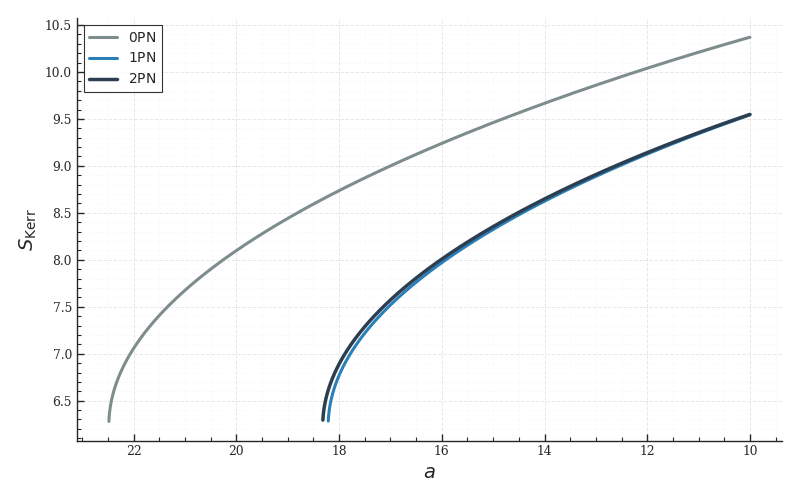

In [219]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(a_prec, ENT_0PN, label=r"$0{\rm PN}$", color="#7f8c8d", lw=2.2)
ax.plot(a_prec, ENT_1PN, label=r"$1{\rm PN}$", color="#2980b9", lw=2.2)
ax.plot(a_prec, ENT_2PN, label=r"$2{\rm PN}$", color="#2c3e50", lw=2.5)
ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.45)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.25)
ax.legend(
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="best"
)
sns.despine()
plt.tight_layout()
plt.show()

PADE'

In [220]:
def fit_pade_2_1(
    x,
    y,
    sigma,
    y_scale=None,
    n_starts=10,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=30000,
    progress_label="Padé [2/1] fit"
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if len(x) < 10:
        raise RuntimeError(f"Too few valid points for {progress_label}: {len(x)}")

    if y_scale is None or not np.isfinite(y_scale) or y_scale == 0.0:
        y_scale = 1.0

    lower_bounds = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds = np.array([np.inf, np.inf, np.inf, np.inf], dtype=float)

    def residuals(params):
        y_model = pade_2_1(x, *params)
        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)
        return res

    rng = np.random.default_rng(random_seed)

    starts = [
        np.array(
            [
                np.nanmedian(y),
                0.0,
                0.0,
                0.1
            ],
            dtype=float
        )
    ]

    for _ in range(n_starts - 1):
        starts.append(
            np.array(
                [
                    np.nanmedian(y),
                    rng.normal(loc=0.0, scale=0.2 * y_scale),
                    rng.normal(loc=0.0, scale=0.2 * y_scale),
                    rng.uniform(low=0.0, high=1.0)
                ],
                dtype=float
            )
        )

    best_result = None
    best_cost = np.inf
    last_exception = None

    iterator = tqdm(
        starts,
        desc=progress_label,
        total=len(starts),
        leave=True
    )

    for p0 in iterator:
        try:
            result = least_squares(
                residuals,
                p0,
                bounds=(lower_bounds, upper_bounds),
                loss=loss,
                f_scale=f_scale,
                x_scale="jac",
                max_nfev=max_nfev
            )

            if result.success and np.isfinite(result.cost) and result.cost < best_cost:
                best_result = result
                best_cost = result.cost

            iterator.set_postfix(best_cost=f"{best_cost:.3e}")

        except Exception as exc:
            last_exception = exc
            iterator.set_postfix(error=str(exc)[:40])
            continue

    if best_result is None:
        raise RuntimeError(
            "Padé [2/1] fit failed.\n"
            f"Last exception: {repr(last_exception)}"
        )

    return best_result.x, best_result

def run_pade_entropy_extrapolation(
    pn_label,
    a_arr,
    M_arr,
    J_arr,
    S_arr,
    m_ref,
    a_merger,
    a_extrap_max=15.0,
    a_extrap_min=1.0,
    n_extrap=10000,
    sigma_power=3.0,
    n_starts_Ebind=10,
    n_starts_chi=10
):
    a_arr = np.asarray(a_arr, dtype=float)
    M_arr = np.asarray(M_arr, dtype=float)
    J_arr = np.asarray(J_arr, dtype=float)
    S_arr = np.asarray(S_arr, dtype=float)

    valid_mask = (
        np.isfinite(S_arr)
        & np.isfinite(a_arr)
        & np.isfinite(M_arr)
        & np.isfinite(J_arr)
        & (a_arr > 0)
        & (M_arr > 0)
    )

    a_valid = a_arr[valid_mask]
    M_valid = M_arr[valid_mask]
    J_valid = J_arr[valid_mask]
    S_valid = S_arr[valid_mask]

    sort_idx = np.argsort(a_valid)

    a_fit = a_valid[sort_idx]
    M_fit = M_valid[sort_idx]
    J_fit = J_valid[sort_idx]
    S_fit = S_valid[sort_idx]

    x_fit = 1.0 / np.sqrt(a_fit)

    Ebind_fit = M_fit - m_ref
    chi_fit = J_fit / M_fit**2

    fit_mask = (
        np.isfinite(x_fit)
        & np.isfinite(Ebind_fit)
        & np.isfinite(chi_fit)
        & (np.abs(chi_fit) <= 1.0)
    )

    a_fit = a_fit[fit_mask]
    x_fit = x_fit[fit_mask]
    M_fit = M_fit[fit_mask]
    J_fit = J_fit[fit_mask]
    S_fit = S_fit[fit_mask]
    Ebind_fit = Ebind_fit[fit_mask]
    chi_fit = chi_fit[fit_mask]

    if len(x_fit) < 10:
        raise RuntimeError(f"Too few valid points for {pn_label}: {len(x_fit)}")

    a_min_fit = np.nanmin(a_fit)
    sigma_fit = (a_fit / a_min_fit)**sigma_power

    popt_Ebind, result_Ebind = fit_pade_2_1(
        x=x_fit,
        y=Ebind_fit,
        sigma=sigma_fit,
        y_scale=np.nanstd(Ebind_fit),
        n_starts=n_starts_Ebind,
        random_seed=1234,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=30000,
        progress_label=fr"{pn_label}: fitting $E_{{\rm bind}}$"
    )

    popt_chi, result_chi = fit_pade_2_1(
        x=x_fit,
        y=chi_fit,
        sigma=sigma_fit,
        y_scale=np.nanstd(chi_fit),
        n_starts=n_starts_chi,
        random_seed=4321,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=15000,
        progress_label=fr"{pn_label}: fitting $\chi$"
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    x_extrap = 1.0 / np.sqrt(a_extrap)

    Ebind_extrap = pade_2_1(x_extrap, *popt_Ebind)
    chi_extrap = pade_2_1(x_extrap, *popt_chi)

    M_extrap = m_ref + Ebind_extrap
    J_extrap = chi_extrap * M_extrap**2

    physical_mask = (
        np.isfinite(M_extrap)
        & np.isfinite(chi_extrap)
        & np.isfinite(J_extrap)
        & (M_extrap > 0)
        & (np.abs(chi_extrap) <= 1.0)
        & (np.abs(J_extrap) <= M_extrap**2)
    )

    ENT_extrap = np.full_like(a_extrap, np.nan, dtype=float)

    ENT_extrap[physical_mask] = entropy(
        M_extrap[physical_mask],
        J_extrap[physical_mask]
    )

    if np.all(np.isnan(ENT_extrap)):
        raise RuntimeError(
            f"The Padé [2/1] extrapolated curve for {pn_label} has no physical points."
        )

    idx_max = np.nanargmax(ENT_extrap)

    a_max_entropy = a_extrap[idx_max]
    S_max_entropy = ENT_extrap[idx_max]
    M_at_max = M_extrap[idx_max]
    J_at_max = J_extrap[idx_max]
    chi_at_max = chi_extrap[idx_max]
    delta_a = np.abs(a_max_entropy - a_merger)

    flags = []

    if idx_max == 0:
        flags.append("maximum_at_upper_boundary")

    if idx_max == len(a_extrap) - 1:
        flags.append("maximum_at_lower_boundary")

    if len(flags) == 0:
        flags.append("OK")

    result_row = {
        "PN_order": pn_label,
        "model": "Padé [2/1]",
        "a_max": a_max_entropy,
        "S_max": S_max_entropy,
        "M_at_max": M_at_max,
        "J_at_max": J_at_max,
        "chi_at_max": chi_at_max,
        "a_merger_NR": a_merger,
        "delta_a": delta_a,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev,
        "flags": ", ".join(flags)
    }

    curve_dict = {
        "a_extrap": a_extrap,
        "x_extrap": x_extrap,
        "Ebind_extrap": Ebind_extrap,
        "M_extrap": M_extrap,
        "J_extrap": J_extrap,
        "chi_extrap": chi_extrap,
        "ENT_extrap": ENT_extrap,
        "popt_Ebind": popt_Ebind,
        "popt_chi": popt_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask,
        "idx_max": idx_max
    }

    return result_row, curve_dict


try:
    m_ref = float(m1 + m2)
except NameError:
    try:
        m_ref = float(m1 + m2)
    except Exception:
        m_ref = 1.0


pade_inputs = {
    "0PN": {
        "a": a_prec,
        "M": E_tot_0PN,
        "J": J_tot_0PN,
        "S": ENT_0PN
    },
    "1PN": {
        "a": a_prec,
        "M": E_tot_1PN,
        "J": J_tot_1PN,
        "S": ENT_1PN
    },
    "2PN": {
        "a": a_prec,
        "M": E_tot_2PN,
        "J": J_tot_2PN,
        "S": ENT_2PN
    }
}


pade_results_all = []
pade_curves_all = {}

for pn_label, data in pade_inputs.items():
    result_row, curve_dict = run_pade_entropy_extrapolation(
        pn_label=pn_label,
        a_arr=data["a"],
        M_arr=data["M"],
        J_arr=data["J"],
        S_arr=data["S"],
        m_ref=m_ref,
        a_merger=a_merger,
        a_extrap_max=15.0,
        a_extrap_min=1.0,
        n_extrap=100000,
        sigma_power=3.0,
        n_starts_Ebind=5,
        n_starts_chi=5
    )

    pade_results_all.append(result_row)
    pade_curves_all[pn_label] = curve_dict


results_pade_all_df = pd.DataFrame(pade_results_all)

print("============================================================")
print("PADÉ [2/1] EXTRAPOLATION")
print("============================================================")

for _, row in results_pade_all_df.iterrows():
    print(f"{row['PN_order']}  {row['model']}")
    print(f"  a_max      = {row['a_max']:.6f}")
    print(f"  a_merger   = {row['a_merger_NR']:.6f}")
    print(f"  Delta a    = {row['delta_a']:.6f}")
    print(f"  flags      = {row['flags']}")
    print("------------------------------------------------------------")

0PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

0PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

1PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

1PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

2PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

2PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

PADÉ [2/1] EXTRAPOLATION
0PN  Padé [2/1]
  a_max      = 3.709727
  a_merger   = 3.146211
  Delta a    = 0.563516
  flags      = OK
------------------------------------------------------------
1PN  Padé [2/1]
  a_max      = 3.212302
  a_merger   = 3.146211
  Delta a    = 0.066091
  flags      = OK
------------------------------------------------------------
2PN  Padé [2/1]
  a_max      = 3.670527
  a_merger   = 3.146211
  Delta a    = 0.524315
  flags      = OK
------------------------------------------------------------


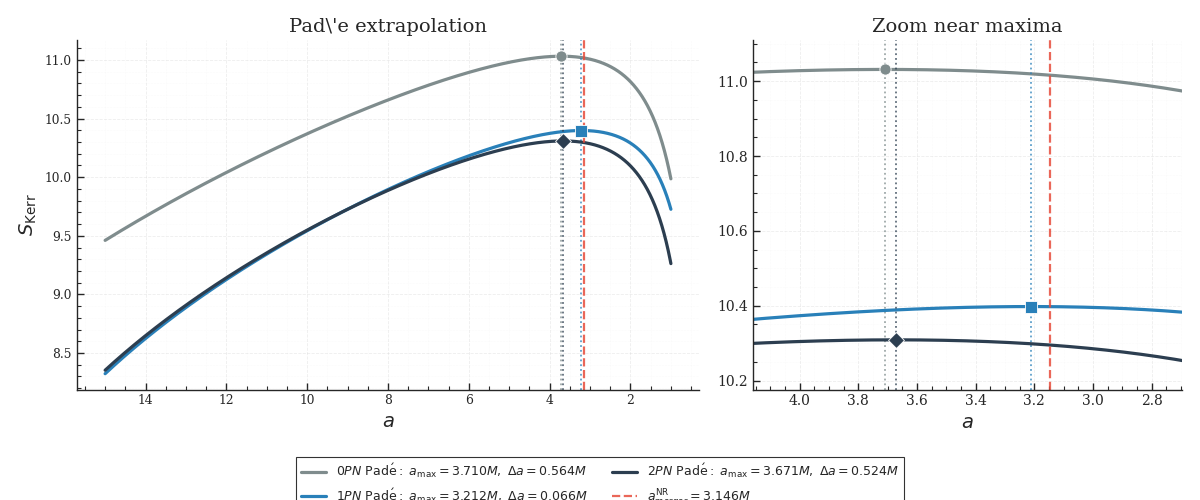

In [221]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

colors = {
    "0PN": "#7f8c8d",
    "1PN": "#2980b9",
    "2PN": "#2c3e50"
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D"
}

# Create subplots for main view and zoom view
fig, (ax, axz) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

curve_data = {}
focus_a_values = [a_merger]

# 1. Main Plot Loop
for pn_label in pn_labels:
    curve = pade_curves_all[pn_label]
    row = results_pade_all_df.loc[results_pade_all_df["PN_order"] == pn_label].iloc[0]
    
    a_extrap_i = curve["a_extrap"]
    ENT_extrap_i = curve["ENT_extrap"]
    
    a_max_i = row["a_max"]
    delta_a_i = row["delta_a"]
    
    sort_idx_i = np.argsort(a_extrap_i)
    a_sorted_i = a_extrap_i[sort_idx_i]
    ent_sorted_i = ENT_extrap_i[sort_idx_i]
    
    # Filter for valid finite values to ensure safe interpolation
    valid_i = np.isfinite(a_sorted_i) & np.isfinite(ent_sorted_i)
    a_sorted_valid = a_sorted_i[valid_i]
    ent_sorted_valid = ent_sorted_i[valid_i]
    
    y_at_max_i = np.interp(a_max_i, a_sorted_valid, ent_sorted_valid)
    
    # Store data to replicate on zoom plot
    curve_data[pn_label] = {
        "a": a_extrap_i,
        "ent": ENT_extrap_i,
        "a_sorted_valid": a_sorted_valid,
        "ent_sorted_valid": ent_sorted_valid,
        "a_max": a_max_i,
        "y_max": y_at_max_i,
        "delta_a": delta_a_i,
    }
    
    focus_a_values.append(a_max_i)
    
    label_i = fr"${pn_label}\ \mathrm{{Pad\acute{{e}}}}:\ a_{{\max}}={a_max_i:.3f}M,\ \Delta a={delta_a_i:.3f}M$"
    
    ax.plot(a_extrap_i, ENT_extrap_i, color=colors[pn_label], lw=2.3, label=label_i)
    ax.scatter(a_max_i, y_at_max_i, marker=markers[pn_label], s=65, color=colors[pn_label], zorder=5, edgecolor="white", linewidth=0.6)
    ax.axvline(a_max_i, color=colors[pn_label], linestyle=":", lw=1.3, alpha=0.75)

ax.axvline(
    a_merger, 
    color="#e74c3c", 
    linestyle="--", 
    lw=1.6, 
    alpha=0.85, 
    label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.set_title(r"Pad\'e extrapolation")

# 2. Dynamic Zoom Calculation
a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45
x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:
    a_vals = curve_data[pn_label]["a_sorted_valid"]
    ent_vals = curve_data[pn_label]["ent_sorted_valid"]
    
    # Filter points within the new x zoom window to find relevant y bounds
    focus_mask = (a_vals >= x_low) & (a_vals <= x_high)
    y_focus_values.extend(ent_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)
y_margin = 0.10 * (ymax_focus - ymin_focus)

# 3. Zoom Plot Construction
for pn_label in pn_labels:
    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["ent"],
        color=colors[pn_label],
        lw=2.3
    )
    axz.scatter(
        curve_data[pn_label]["a_max"],
        curve_data[pn_label]["y_max"],
        marker=markers[pn_label],
        s=65,
        color=colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )
    axz.axvline(
        curve_data[pn_label]["a_max"],
        color=colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.75
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.85
)

axz.set_xlim(x_high, x_low)  # (High to low handles the axis inversion automatically)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)
axz.set_xlabel(r"$a$")
axz.set_title("Zoom near maxima")
axz.tick_params(axis="both", labelsize=10)

# 4. Styling and Universal Legends
for axis in [ax, axz]:
    axis.minorticks_on()
    axis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    axis.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=2
)

sns.despine()
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

TAYLOR

In [222]:
def taylor_model_scaled(x, coeffs, x_center, x_scale):
    x = np.asarray(x, dtype=float)
    z = (x - x_center) / x_scale
    y = np.zeros_like(z, dtype=float)
    for k, ck in enumerate(coeffs):
        y += ck * z**k
    return y

def fit_taylor_scaled(
    x,
    y,
    sigma,
    degree=3,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=50000,
    progress_label="Taylor fit"
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if len(x) <= degree + 1:
        raise RuntimeError(
            f"Not enough points for Taylor degree {degree}: n_points = {len(x)}."
        )

    x_center = np.nanmean(x)
    x_scale = np.nanstd(x)

    if not np.isfinite(x_scale) or x_scale == 0.0:
        x_scale = 1.0

    z = (x - x_center) / x_scale

    poly_coeff_high_to_low = np.polyfit(
        z,
        y,
        deg=degree,
        w=1.0 / sigma
    )

    p0 = poly_coeff_high_to_low[::-1]

    def residuals(coeffs):
        y_model = taylor_model_scaled(
            x,
            coeffs,
            x_center=x_center,
            x_scale=x_scale
        )

        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)

        return res

    result = least_squares(
        residuals,
        p0,
        loss=loss,
        f_scale=f_scale,
        x_scale="jac",
        max_nfev=max_nfev
    )

    if not result.success:
        raise RuntimeError(
            f"{progress_label} failed: {result.message}"
        )

    return result.x, x_center, x_scale, result

def run_taylor_entropy_extrapolation(
    pn_label,
    a_arr,
    M_arr,
    J_arr,
    S_arr,
    m_ref,
    a_merger,
    degree_Ebind=3,
    degree_chi=3,
    a_extrap_max=15.0,
    a_extrap_min=1.0,
    n_extrap=10000,
    sigma_power=1.0
):
    a_arr = np.asarray(a_arr, dtype=float)
    M_arr = np.asarray(M_arr, dtype=float)
    J_arr = np.asarray(J_arr, dtype=float)
    S_arr = np.asarray(S_arr, dtype=float)

    valid_mask = (
        np.isfinite(S_arr)
        & np.isfinite(a_arr)
        & np.isfinite(M_arr)
        & np.isfinite(J_arr)
        & (a_arr > 0)
        & (M_arr > 0)
    )

    a_valid = a_arr[valid_mask]
    M_valid = M_arr[valid_mask]
    J_valid = J_arr[valid_mask]
    S_valid = S_arr[valid_mask]

    sort_idx = np.argsort(a_valid)

    a_fit = a_valid[sort_idx]
    M_fit = M_valid[sort_idx]
    J_fit = J_valid[sort_idx]
    S_fit = S_valid[sort_idx]

    x_fit = 1.0 / np.sqrt(a_fit)

    Ebind_fit = M_fit - m_ref
    chi_fit = J_fit / M_fit**2

    fit_mask = (
        np.isfinite(x_fit)
        & np.isfinite(Ebind_fit)
        & np.isfinite(chi_fit)
        & (np.abs(chi_fit) <= 1.0)
    )

    a_fit = a_fit[fit_mask]
    x_fit = x_fit[fit_mask]
    M_fit = M_fit[fit_mask]
    J_fit = J_fit[fit_mask]
    S_fit = S_fit[fit_mask]
    Ebind_fit = Ebind_fit[fit_mask]
    chi_fit = chi_fit[fit_mask]

    if len(x_fit) < 20:
        raise RuntimeError(
            f"Too few valid points for a reliable Taylor fit for {pn_label}: {len(x_fit)}"
        )

    a_min_fit = np.nanmin(a_fit)
    sigma_fit = (a_fit / a_min_fit)**sigma_power

    coeff_Ebind, x_center_Ebind, x_scale_Ebind, result_Ebind = fit_taylor_scaled(
        x=x_fit,
        y=Ebind_fit,
        sigma=sigma_fit,
        degree=degree_Ebind,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=30000,
        progress_label=f"{pn_label}: fitting E_bind with Taylor"
    )

    coeff_chi, x_center_chi, x_scale_chi, result_chi = fit_taylor_scaled(
        x=x_fit,
        y=chi_fit,
        sigma=sigma_fit,
        degree=degree_chi,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=15000,
        progress_label=f"{pn_label}: fitting chi with Taylor"
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    x_extrap = 1.0 / np.sqrt(a_extrap)

    Ebind_extrap = taylor_model_scaled(
        x_extrap,
        coeff_Ebind,
        x_center=x_center_Ebind,
        x_scale=x_scale_Ebind
    )

    chi_extrap = taylor_model_scaled(
        x_extrap,
        coeff_chi,
        x_center=x_center_chi,
        x_scale=x_scale_chi
    )

    M_extrap = m_ref + Ebind_extrap
    J_extrap = chi_extrap * M_extrap**2

    physical_mask = (
        np.isfinite(M_extrap)
        & np.isfinite(chi_extrap)
        & np.isfinite(J_extrap)
        & (M_extrap > 0)
        & (np.abs(chi_extrap) <= 1.0)
        & (np.abs(J_extrap) <= M_extrap**2)
    )

    ENT_extrap = np.full_like(a_extrap, np.nan, dtype=float)

    ENT_extrap[physical_mask] = entropy(
        M_extrap[physical_mask],
        J_extrap[physical_mask]
    )

    if np.all(np.isnan(ENT_extrap)):
        raise RuntimeError(
            f"The Taylor-extrapolated curve for {pn_label} contains no valid physical points."
        )

    idx_max = np.nanargmax(ENT_extrap)

    a_max_entropy = a_extrap[idx_max]
    S_max_entropy = ENT_extrap[idx_max]
    M_at_max = M_extrap[idx_max]
    J_at_max = J_extrap[idx_max]
    chi_at_max = chi_extrap[idx_max]
    delta_a = np.abs(a_max_entropy - a_merger)

    flags = []

    if idx_max == 0:
        flags.append("maximum_at_upper_boundary")

    if idx_max == len(a_extrap) - 1:
        flags.append("maximum_at_lower_boundary")

    if not (np.nanmin(a_extrap) <= a_merger <= np.nanmax(a_extrap)):
        flags.append("a_merger_outside_extrapolation_range")

    if len(flags) == 0:
        flags.append("OK")

    result_row = {
        "PN_order": pn_label,
        "model": f"Taylor degree {degree_Ebind}",
        "degree_Ebind": degree_Ebind,
        "degree_chi": degree_chi,
        "a_max": a_max_entropy,
        "S_max": S_max_entropy,
        "M_at_max": M_at_max,
        "J_at_max": J_at_max,
        "chi_at_max": chi_at_max,
        "a_merger_NR": a_merger,
        "delta_a": delta_a,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev,
        "flags": ", ".join(flags)
    }

    curve_dict = {
        "a_extrap": a_extrap,
        "x_extrap": x_extrap,
        "Ebind_extrap": Ebind_extrap,
        "M_extrap": M_extrap,
        "J_extrap": J_extrap,
        "chi_extrap": chi_extrap,
        "ENT_extrap": ENT_extrap,
        "coeff_Ebind": coeff_Ebind,
        "coeff_chi": coeff_chi,
        "x_center_Ebind": x_center_Ebind,
        "x_scale_Ebind": x_scale_Ebind,
        "x_center_chi": x_center_chi,
        "x_scale_chi": x_scale_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask,
        "idx_max": idx_max
    }

    return result_row, curve_dict

try:
    m_ref = float(m1 + m2)
except NameError:
    try:
        m_ref = float(m1 + m2)
    except NameError:
        m_ref = 1.0

taylor_inputs = {
    "0PN": {
        "a": a_prec,
        "M": E_tot_0PN,
        "J": J_tot_0PN,
        "S": ENT_0PN
    },
    "1PN": {
        "a": a_prec,
        "M": E_tot_1PN,
        "J": J_tot_1PN,
        "S": ENT_1PN
    },
    "2PN": {
        "a": a_prec,
        "M": E_tot_2PN,
        "J": J_tot_2PN,
        "S": ENT_2PN
    }
}

taylor_results_all = []
taylor_curves_all = {}

for pn_label, data in taylor_inputs.items():
    result_row, curve_dict = run_taylor_entropy_extrapolation(
        pn_label=pn_label,
        a_arr=data["a"],
        M_arr=data["M"],
        J_arr=data["J"],
        S_arr=data["S"],
        m_ref=m_ref,
        a_merger=a_merger,
        degree_Ebind=3,
        degree_chi=3,
        a_extrap_max=15.0,
        a_extrap_min=1.0,
        n_extrap=10000,
        sigma_power=1.0
    )

    taylor_results_all.append(result_row)
    taylor_curves_all[pn_label] = curve_dict

results_taylor_all_df = pd.DataFrame(taylor_results_all)



print("============================================================")
print("TAYLOR EXTRAPOLATION ")
print("============================================================")

for _, row in results_taylor_all_df.iterrows():
    print(f"{row['PN_order']}:")
    print(f"  a_max      = {row['a_max']:.6f}")
    print(f"  a_merger   = {row['a_merger_NR']:.6f}")
    print(f"  Delta a    = {row['delta_a']:.6f}")
    print(f"  flags      = {row['flags']}")
    print("------------------------------------------------------------")

print("============================================================")

TAYLOR EXTRAPOLATION 
0PN:
  a_max      = 3.261226
  a_merger   = 3.146211
  Delta a    = 0.115015
  flags      = OK
------------------------------------------------------------
1PN:
  a_max      = 2.603160
  a_merger   = 3.146211
  Delta a    = 0.543051
  flags      = OK
------------------------------------------------------------
2PN:
  a_max      = 2.584958
  a_merger   = 3.146211
  Delta a    = 0.561253
  flags      = OK
------------------------------------------------------------


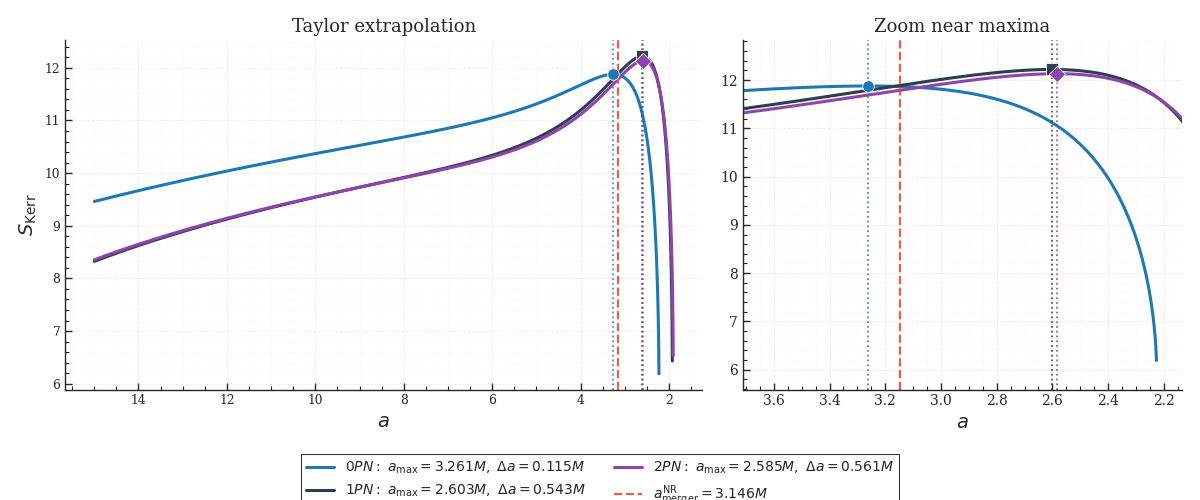

In [223]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

curve_colors = {
    "0PN": "#1f77b4",
    "1PN": "#2c3e50",
    "2PN": "#8e44ad",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

curve_data = {}
focus_a_values = [a_merger]

for pn_label in pn_labels:
    row = results_taylor_all_df.loc[
        results_taylor_all_df["PN_order"] == pn_label
    ].iloc[0]

    a_taylor = taylor_curves_all[pn_label]["a_extrap"]
    ENT_taylor = taylor_curves_all[pn_label]["ENT_extrap"]

    a_max_taylor = row["a_max"]
    delta_a_taylor = row["delta_a"]

    sort_idx = np.argsort(a_taylor)
    a_sorted = a_taylor[sort_idx]
    ent_sorted = ENT_taylor[sort_idx]

    valid_interp_mask = np.isfinite(a_sorted) & np.isfinite(ent_sorted)

    a_sorted_valid = a_sorted[valid_interp_mask]
    ent_sorted_valid = ent_sorted[valid_interp_mask]

    y_at_max_taylor = np.interp(
        a_max_taylor,
        a_sorted_valid,
        ent_sorted_valid
    )

    curve_data[pn_label] = {
        "a": a_taylor,
        "ent": ENT_taylor,
        "a_sorted_valid": a_sorted_valid,
        "ent_sorted_valid": ent_sorted_valid,
        "a_max": a_max_taylor,
        "y_max": y_at_max_taylor,
        "delta_a": delta_a_taylor,
    }

    focus_a_values.append(a_max_taylor)

    label_i = (
        fr"${pn_label}:\ "
        fr"a_{{\max}}={a_max_taylor:.3f}M,\ "
        fr"\Delta a={delta_a_taylor:.3f}M$"
    )

    ax.plot(
        a_taylor,
        ENT_taylor,
        color=curve_colors[pn_label],
        lw=2.2,
        label=label_i
    )

    ax.scatter(
        a_max_taylor,
        y_at_max_taylor,
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_max_taylor,
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.8
    )

ax.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9,
    label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.set_title("Taylor extrapolation")

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45
x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:
    a_vals = curve_data[pn_label]["a_sorted_valid"]
    ent_vals = curve_data[pn_label]["ent_sorted_valid"]

    focus_mask = (a_vals >= x_low) & (a_vals <= x_high)

    y_focus_values.extend(ent_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)
y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:
    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["ent"],
        color=curve_colors[pn_label],
        lw=2.2
    )

    axz.scatter(
        curve_data[pn_label]["a_max"],
        curve_data[pn_label]["y_max"],
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_max"],
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.85
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)
axz.set_xlabel(r"$a$")
axz.set_title("Zoom near maxima")
axz.tick_params(axis="both", labelsize=10)

for axis in [ax, axz]:
    axis.minorticks_on()
    axis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    axis.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=2
)

sns.despine()

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

Taylor's stability

TAYLOR SENSITIVITY ANALYSIS


,PN_order,degree,sigma_power,a_max,a_merger_NR,delta_a,flags,status
0,0PN,2,1.0,6.971597,3.146211,3.825386,OK,success
1,0PN,2,2.0,6.817582,3.146211,3.671370,OK,success
2,0PN,2,3.0,6.670567,3.146211,3.524356,OK,success
3,0PN,2,4.0,6.527753,3.146211,3.381541,OK,success
4,0PN,3,1.0,3.261226,3.146211,0.115015,OK,success
5,0PN,3,2.0,3.196820,3.146211,0.050608,OK,success
6,0PN,3,3.0,3.132413,3.146211,0.013798,OK,success
7,0PN,3,4.0,3.070807,3.146211,0.075404,OK,success
8,0PN,4,1.0,6.012501,3.146211,2.866290,OK,success
9,0PN,4,2.0,5.934093,3.146211,2.787882,OK,success


SUMMARY BY PN ORDER


,PN_order,n_success,mean_a_max,median_a_max,std_a_max,min_a_max,max_a_max,mean_delta_a,median_delta_a,std_delta_a,min_delta_a,max_delta_a
0,0PN,12,5.269844,5.896290,1.600457,3.070807,6.971597,2.138499,2.750078,1.578713,0.013798,3.825386
1,1PN,12,4.943844,5.612761,1.823337,2.502350,6.792379,2.193270,2.466550,1.265727,0.543051,3.646168
2,2PN,12,5.038004,5.786379,1.901538,2.479948,6.919792,2.301431,2.640167,1.319843,0.561253,3.773581


BEST CONFIGURATION FOR EACH PN ORDER


,PN_order,degree,sigma_power,a_max,a_merger_NR,delta_a,flags
0,0PN,3,3.0,3.132413,3.146211,0.013798,OK
1,1PN,3,1.0,2.603160,3.146211,0.543051,OK
2,2PN,3,1.0,2.584958,3.146211,0.561253,OK


REFERENCE CONFIGURATION: degree = 3, sigma_power = 3


,PN_order,degree,sigma_power,a_max,a_merger_NR,delta_a,flags
0,0PN,3,3.0,3.132413,3.146211,0.013798,OK
1,1PN,3,3.0,2.535954,3.146211,0.610258,OK
2,2PN,3,3.0,2.513551,3.146211,0.632660,OK


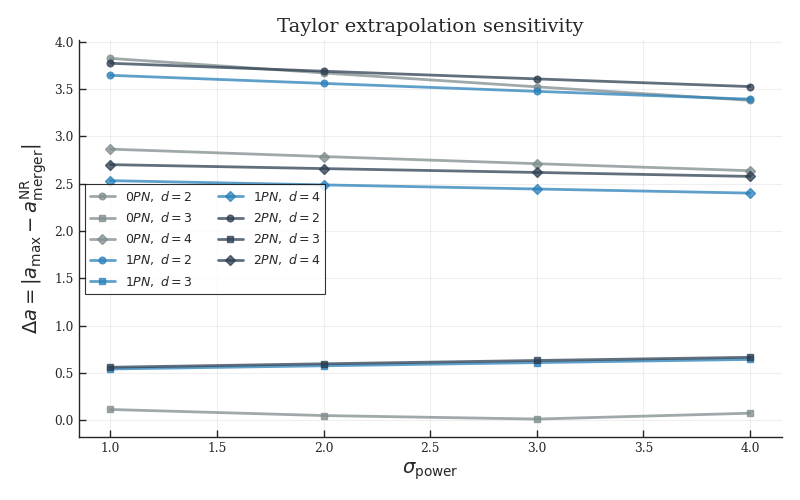

In [224]:
degree_grid = [2, 3, 4]
sigma_power_grid = [1.0, 2.0, 3.0, 4.0]

try:
    m_ref = float(m1 + m2)
except Exception:
    try:
        m_ref = float(m1 + m2)
    except Exception:
        m_ref = 1.0


taylor_inputs_sensitivity = {
    "0PN": {
        "a": a_prec,
        "M": E_tot_0PN,
        "J": J_tot_0PN,
        "S": ENT_0PN
    },
    "1PN": {
        "a": a_prec,
        "M": E_tot_1PN,
        "J": J_tot_1PN,
        "S": ENT_1PN
    },
    "2PN": {
        "a": a_prec,
        "M": E_tot_2PN,
        "J": J_tot_2PN,
        "S": ENT_2PN
    }
}


taylor_sensitivity_results = []
taylor_sensitivity_curves = {}

for pn_label, data in taylor_inputs_sensitivity.items():

    for degree in degree_grid:

        for sigma_power in sigma_power_grid:

            key = (pn_label, degree, sigma_power)

            try:
                result_row, curve_dict = run_taylor_entropy_extrapolation(
                    pn_label=pn_label,
                    a_arr=data["a"],
                    M_arr=data["M"],
                    J_arr=data["J"],
                    S_arr=data["S"],
                    m_ref=m_ref,
                    a_merger=a_merger,
                    degree_Ebind=degree,
                    degree_chi=degree,
                    a_extrap_max=15.0,
                    a_extrap_min=1.0,
                    n_extrap=10000,
                    sigma_power=sigma_power
                )

                result_row["degree"] = degree
                result_row["sigma_power"] = sigma_power
                result_row["status"] = "success"
                result_row["error"] = ""

                taylor_sensitivity_results.append(result_row)
                taylor_sensitivity_curves[key] = curve_dict

            except Exception as exc:

                taylor_sensitivity_results.append(
                    {
                        "PN_order": pn_label,
                        "model": f"Taylor degree {degree}",
                        "degree_Ebind": degree,
                        "degree_chi": degree,
                        "degree": degree,
                        "sigma_power": sigma_power,
                        "a_max": np.nan,
                        "S_max": np.nan,
                        "M_at_max": np.nan,
                        "J_at_max": np.nan,
                        "chi_at_max": np.nan,
                        "a_merger_NR": a_merger,
                        "delta_a": np.nan,
                        "cost_Ebind": np.nan,
                        "cost_chi": np.nan,
                        "nfev_Ebind": np.nan,
                        "nfev_chi": np.nan,
                        "flags": "failed",
                        "status": "failed",
                        "error": str(exc)
                    }
                )


taylor_sensitivity_df = pd.DataFrame(taylor_sensitivity_results)

successful_taylor_sensitivity_df = (
    taylor_sensitivity_df[
        taylor_sensitivity_df["status"] == "success"
    ]
    .copy()
)


print("============================================================")
print("TAYLOR SENSITIVITY ANALYSIS")
print("============================================================")

display(
    taylor_sensitivity_df[
        [
            "PN_order",
            "degree",
            "sigma_power",
            "a_max",
            "a_merger_NR",
            "delta_a",
            "flags",
            "status"
        ]
    ]
    .sort_values(
        [
            "PN_order",
            "degree",
            "sigma_power"
        ]
    )
    .reset_index(drop=True)
)


print("============================================================")
print("SUMMARY BY PN ORDER")
print("============================================================")

summary_taylor_sensitivity_df = (
    successful_taylor_sensitivity_df
    .groupby("PN_order")
    .agg(
        n_success=("delta_a", "count"),
        mean_a_max=("a_max", "mean"),
        median_a_max=("a_max", "median"),
        std_a_max=("a_max", "std"),
        min_a_max=("a_max", "min"),
        max_a_max=("a_max", "max"),
        mean_delta_a=("delta_a", "mean"),
        median_delta_a=("delta_a", "median"),
        std_delta_a=("delta_a", "std"),
        min_delta_a=("delta_a", "min"),
        max_delta_a=("delta_a", "max")
    )
    .reset_index()
)

display(summary_taylor_sensitivity_df)


print("============================================================")
print("BEST CONFIGURATION FOR EACH PN ORDER")
print("============================================================")

best_taylor_sensitivity_df = (
    successful_taylor_sensitivity_df
    .sort_values(
        [
            "PN_order",
            "delta_a"
        ]
    )
    .groupby("PN_order")
    .head(1)
    .reset_index(drop=True)
)

display(
    best_taylor_sensitivity_df[
        [
            "PN_order",
            "degree",
            "sigma_power",
            "a_max",
            "a_merger_NR",
            "delta_a",
            "flags"
        ]
    ]
)


print("============================================================")
print("REFERENCE CONFIGURATION: degree = 3, sigma_power = 3")
print("============================================================")

reference_taylor_sensitivity_df = (
    successful_taylor_sensitivity_df[
        (successful_taylor_sensitivity_df["degree"] == 3)
        &
        (successful_taylor_sensitivity_df["sigma_power"] == 3.0)
    ]
    .copy()
)

display(
    reference_taylor_sensitivity_df[
        [
            "PN_order",
            "degree",
            "sigma_power",
            "a_max",
            "a_merger_NR",
            "delta_a",
            "flags"
        ]
    ]
    .reset_index(drop=True)
)


sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

colors = {
    "0PN": "#7f8c8d",
    "1PN": "#2980b9",
    "2PN": "#2c3e50"
}

markers = {
    2: "o",
    3: "s",
    4: "D"
}

fig, ax = plt.subplots(figsize=(8, 5))

for pn_label in ["0PN", "1PN", "2PN"]:

    for degree in degree_grid:

        subset = successful_taylor_sensitivity_df[
            (successful_taylor_sensitivity_df["PN_order"] == pn_label)
            &
            (successful_taylor_sensitivity_df["degree"] == degree)
        ].copy()

        subset = subset.sort_values("sigma_power")

        if len(subset) == 0:
            continue

        ax.plot(
            subset["sigma_power"],
            subset["delta_a"],
            marker=markers[degree],
            lw=2.0,
            color=colors[pn_label],
            alpha=0.75,
            label=fr"${pn_label},\ d={degree}$"
        )

ax.set_xlabel(r"$\sigma_{\rm power}$")
ax.set_ylabel(r"$\Delta a = |a_{\max}-a_{\rm merger}^{\rm NR}|$")
ax.set_title(r"Taylor extrapolation sensitivity")

ax.legend(
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="best",
    ncol=2
)

sns.despine()
plt.tight_layout()
plt.show()

2PN analysis

In [168]:
m_ref = 1.0

E_bind_NS_2PN = (
    out_2PN["E_bind_0PN"]
    +
    out_2PN["E_bind_1PN"]
    +
    out_2PN["E_bind_2PN_NS"]
)

E_bind_NS_SO_2PN = (
    E_bind_NS_2PN
    +
    out_2PN["E_bind_SO_15PN"]
)

E_bind_full_2PN = (
    E_bind_NS_SO_2PN
    +
    out_2PN["E_bind_SS_2PN"]
)

M_NS_2PN = m_ref + E_bind_NS_2PN
M_NS_SO_2PN = m_ref + E_bind_NS_SO_2PN
M_full_2PN = m_ref + E_bind_full_2PN


L_vec_NS_2PN = np.stack(
    [
        np.zeros_like(out_2PN["L_NS"]),
        np.zeros_like(out_2PN["L_NS"]),
        out_2PN["L_NS"]
    ],
    axis=-1
)

L_vec_NS_SO_2PN = np.stack(
    [
        out_2PN["L_SO_n_15PN"],
        out_2PN["L_SO_lam_15PN"],
        out_2PN["L_NS"] + out_2PN["L_SO_L_15PN"]
    ],
    axis=-1
)

L_vec_full_2PN = np.stack(
    [
        out_2PN["L_SO_n_15PN"] + out_2PN["L_SS_n_2PN"],
        out_2PN["L_SO_lam_15PN"] + out_2PN["L_SS_lam_2PN"],
        out_2PN["L_NS"] + out_2PN["L_SO_L_15PN"] + out_2PN["L_SS_L_2PN"]
    ],
    axis=-1
)


S_tot_vec = out_2PN["S_tot_vec"]

J_vec_NS_2PN = L_vec_NS_2PN + S_tot_vec
J_vec_NS_SO_2PN = L_vec_NS_SO_2PN + S_tot_vec
J_vec_full_2PN = L_vec_full_2PN + S_tot_vec

J_NS_2PN = np.sqrt(np.sum(J_vec_NS_2PN**2, axis=-1))
J_NS_SO_2PN = np.sqrt(np.sum(J_vec_NS_SO_2PN**2, axis=-1))
J_full_2PN = np.sqrt(np.sum(J_vec_full_2PN**2, axis=-1))


ENT_NS_2PN = entropy(M_NS_2PN, J_NS_2PN)
ENT_NS_SO_2PN = entropy(M_NS_SO_2PN, J_NS_SO_2PN)
ENT_full_2PN_check = entropy(M_full_2PN, J_full_2PN)


twoPN_decomposition = {
    "2PN_NS": {
        "M": M_NS_2PN,
        "J": J_NS_2PN,
        "S": ENT_NS_2PN
    },
    "2PN_NS_SO": {
        "M": M_NS_SO_2PN,
        "J": J_NS_SO_2PN,
        "S": ENT_NS_SO_2PN
    },
    "2PN_FULL": {
        "M": M_full_2PN,
        "J": J_full_2PN,
        "S": ENT_full_2PN_check
    }
}

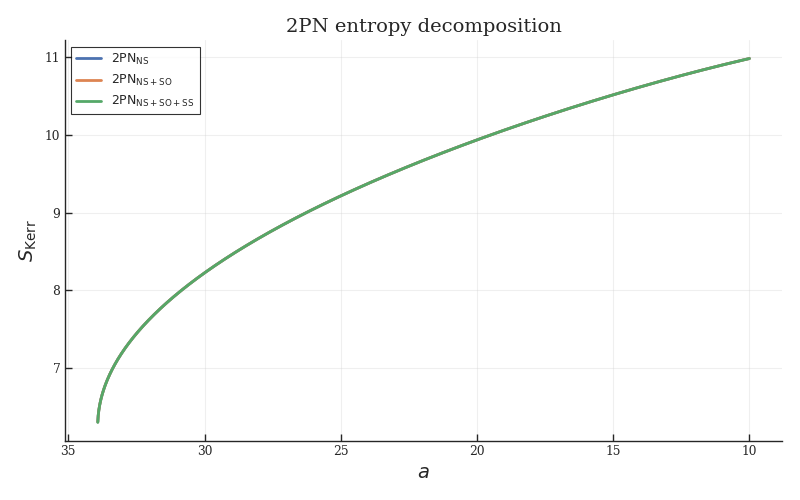

In [169]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    a_prec,
    ENT_NS_2PN,
    lw=2.0,
    label=r"$2{\rm PN}_{\rm NS}$"
)

ax.plot(
    a_prec,
    ENT_NS_SO_2PN,
    lw=2.0,
    label=r"$2{\rm PN}_{\rm NS+SO}$"
)

ax.plot(
    a_prec,
    ENT_full_2PN_check,
    lw=2.0,
    label=r"$2{\rm PN}_{\rm NS+SO+SS}$"
)

ax.invert_xaxis()

ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.set_title(r"2PN entropy decomposition")

ax.legend(
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="best"
)

sns.despine()
plt.tight_layout()
plt.show()

In [170]:
twoPN_decomposition_results = []
twoPN_decomposition_curves = {}

for label, data in twoPN_decomposition.items():

    result_row, curve_dict = run_taylor_entropy_extrapolation(
        pn_label=label,
        a_arr=a_prec,
        M_arr=data["M"],
        J_arr=data["J"],
        S_arr=data["S"],
        m_ref=m_ref,
        a_merger=a_merger,
        degree_Ebind=3,
        degree_chi=3,
        a_extrap_max=15.0,
        a_extrap_min=1.0,
        n_extrap=10000,
        sigma_power=3.0
    )

    twoPN_decomposition_results.append(result_row)
    twoPN_decomposition_curves[label] = curve_dict


twoPN_decomposition_df = pd.DataFrame(twoPN_decomposition_results)

print("============================================================")
print("2PN DECOMPOSITION: TAYLOR EXTRAPOLATION")
print("============================================================")

display(
    twoPN_decomposition_df[
        [
            "PN_order",
            "a_max",
            "a_merger_NR",
            "delta_a",
            "M_at_max",
            "J_at_max",
            "chi_at_max",
            "flags"
        ]
    ]
)

print("============================================================")

2PN DECOMPOSITION: TAYLOR EXTRAPOLATION


,PN_order,a_max,a_merger_NR,delta_a,M_at_max,J_at_max,chi_at_max,flags
0,2PN_NS,3.209421,3.485455,0.276034,0.987150,0.005999,0.006156,OK
1,2PN_NS_SO,3.209421,3.485455,0.276034,0.987150,0.005999,0.006156,OK
2,2PN_FULL,3.209421,3.485455,0.276034,0.987161,0.006182,0.006344,OK


Result Table

In [202]:
def get_optional_variable(name, default=np.nan):
    return globals().get(name, default)


def get_result_value(df, pn_order, column, default=np.nan):
    try:
        row = df.loc[df["PN_order"] == pn_order].iloc[0]
        return row[column]
    except Exception:
        return default


def get_config_metadata():
    metadata = {}

    metadata["q"] = get_optional_variable("q_prec", get_optional_variable("target_q", np.nan))
    metadata["chi1"] = get_optional_variable("chi1", get_optional_variable("target_chi1", np.nan))
    metadata["chi2"] = get_optional_variable("chi2", get_optional_variable("target_chi2", np.nan))

    metadata["theta1_deg"] = get_optional_variable(
        "theta1_0_deg",
        get_optional_variable("target_theta1_deg", np.nan)
    )

    metadata["theta2_deg"] = get_optional_variable(
        "theta2_0_deg",
        get_optional_variable("target_theta2_deg", np.nan)
    )

    metadata["dphi_deg"] = get_optional_variable(
        "deltaphi_0_deg",
        get_optional_variable("dphi_deg", get_optional_variable("target_dphi_deg", np.nan))
    )

    metadata["spin_geometry"] = get_optional_variable(
        "target_spin_geometry",
        get_optional_variable("spin_geometry", "")
    )

    return metadata


def build_final_result_row(results_taylor_all_df, a_merger):
    metadata = get_config_metadata()

    row = {
        "q": metadata["q"],
        "chi1": metadata["chi1"],
        "chi2": metadata["chi2"],
        "theta1_deg": metadata["theta1_deg"],
        "theta2_deg": metadata["theta2_deg"],
        "dphi_deg": metadata["dphi_deg"],
        "spin_geometry": metadata["spin_geometry"],

        "a_merger_NR": a_merger,
    }

    for pn_order in ["0PN", "1PN", "2PN"]:

        row[f"a_max_{pn_order}"] = get_result_value(
            results_taylor_all_df,
            pn_order,
            "a_max"
        )

        row[f"delta_a_{pn_order}"] = get_result_value(
            results_taylor_all_df,
            pn_order,
            "delta_a"
        )

        row[f"S_max_{pn_order}"] = get_result_value(
            results_taylor_all_df,
            pn_order,
            "S_max"
        )

        row[f"M_at_max_{pn_order}"] = get_result_value(
            results_taylor_all_df,
            pn_order,
            "M_at_max"
        )

        row[f"J_at_max_{pn_order}"] = get_result_value(
            results_taylor_all_df,
            pn_order,
            "J_at_max"
        )

        row[f"chi_at_max_{pn_order}"] = get_result_value(
            results_taylor_all_df,
            pn_order,
            "chi_at_max"
        )

        row[f"flags_{pn_order}"] = get_result_value(
            results_taylor_all_df,
            pn_order,
            "flags",
            default=""
        )

    return row


final_result_row = build_final_result_row(
    results_taylor_all_df=results_taylor_all_df,
    a_merger=a_merger
)

final_result_current_df = pd.DataFrame([final_result_row])

display(final_result_current_df)

,q,chi1,chi2,theta1_deg,theta2_deg,dphi_deg,spin_geometry,a_merger_NR,a_max_0PN,delta_a_0PN,...,J_at_max_1PN,chi_at_max_1PN,flags_1PN,a_max_2PN,delta_a_2PN,S_max_2PN,M_at_max_2PN,J_at_max_2PN,chi_at_max_2PN,flags_2PN
0,0.3,0.2,0.2,112.0,41.0,NaN,random_like_2,3.395234,4.29593,0.900696,...,0.009195,0.009455,OK,3.423642,0.028408,12.215671,0.985957,0.008734,0.008985,OK


In [203]:
try:
    final_results_rows
except NameError:
    final_results_rows = []


final_results_rows.append(final_result_row)

final_results_table = pd.DataFrame(final_results_rows)

display(final_results_table)

,q,chi1,chi2,theta1_deg,theta2_deg,dphi_deg,spin_geometry,a_merger_NR,a_max_0PN,delta_a_0PN,...,J_at_max_1PN,chi_at_max_1PN,flags_1PN,a_max_2PN,delta_a_2PN,S_max_2PN,M_at_max_2PN,J_at_max_2PN,chi_at_max_2PN,flags_2PN
0,0.30,0.2,0.2,76.000000,156.000000,NaN,random_like_3,3.141314,3.712071,0.570758,...,0.003067,0.003155,OK,2.950395,0.190919,12.202707,0.985425,0.003199,0.003294,OK
1,0.30,0.2,0.2,179.942704,179.942704,NaN,nearly_antialigned,3.477838,4.606761,1.128923,...,0.012068,0.012404,OK,3.460046,0.017792,12.249514,0.987314,0.003200,0.003283,OK
2,0.25,0.2,0.2,90.000000,179.942704,NaN,one_in_plane_one_antialigned,3.168856,3.964096,0.795241,...,0.006610,0.006779,OK,3.219222,0.050366,12.253004,0.987456,0.005038,0.005167,OK
3,0.25,0.2,0.2,45.000000,150.000000,NaN,primary_tilted_secondary_retrograde,3.194373,3.595860,0.401487,...,0.002250,0.002309,OK,2.951795,0.242578,12.221504,0.986187,0.005668,0.005828,OK
4,0.30,0.4,0.2,30.000000,120.000000,NaN,generic_asymmetric_precessing,3.347202,2.920992,0.426210,...,-0.015426,-0.015828,OK,2.289529,1.057673,12.097225,0.981161,0.006018,0.006252,OK
5,0.25,0.2,0.2,90.000000,90.000000,NaN,in_plane_opposite,3.485455,3.938894,0.453439,...,0.006637,0.006807,OK,3.209421,0.276034,12.245635,0.987161,0.006182,0.006344,OK
6,0.25,0.2,0.2,90.000000,90.000000,NaN,in_plane_same_phase,3.470352,4.308531,0.838179,...,0.009978,0.010230,OK,3.551055,0.080704,12.251409,0.987400,0.009511,0.009756,OK
7,0.25,0.2,0.2,90.000000,90.000000,NaN,in_plane_opposite,3.485455,4.333733,0.848279,...,0.010120,0.010376,OK,3.566457,0.081002,12.251476,0.987403,0.009494,0.009737,OK
8,0.25,0.2,0.2,90.000000,90.000000,NaN,in_plane_oblique_45,3.471336,4.311331,0.839995,...,0.009476,0.009715,OK,3.552455,0.081119,12.251419,0.987400,0.009084,0.009317,OK
9,0.30,0.2,0.2,112.000000,41.000000,NaN,random_like_2,3.395234,4.295930,0.900696,...,0.009195,0.009455,OK,3.423642,0.028408,12.215671,0.985957,0.008734,0.008985,OK


In [204]:
summary_rows = []

for pn_order in ["0PN", "1PN", "2PN"]:

    delta_col = f"delta_a_{pn_order}"
    amax_col = f"a_max_{pn_order}"

    valid = (
        np.isfinite(final_results_table[delta_col])
        &
        np.isfinite(final_results_table[amax_col])
    )

    delta_values = final_results_table.loc[valid, delta_col]
    amax_values = final_results_table.loc[valid, amax_col]

    summary_rows.append(
        {
            "PN_order": pn_order,
            "n_configs": len(delta_values),
            "mean_a_max": np.nanmean(amax_values),
            "median_a_max": np.nanmedian(amax_values),
            "std_a_max": np.nanstd(amax_values),
            "mean_delta_a": np.nanmean(delta_values),
            "median_delta_a": np.nanmedian(delta_values),
            "std_delta_a": np.nanstd(delta_values),
            "min_delta_a": np.nanmin(delta_values),
            "max_delta_a": np.nanmax(delta_values)
        }
    )

final_results_summary_df = pd.DataFrame(summary_rows)

display(final_results_summary_df)

,PN_order,n_configs,mean_a_max,median_a_max,std_a_max,mean_delta_a,median_delta_a,std_delta_a,min_delta_a,max_delta_a
0,0PN,10,3.998820,4.130013,0.466340,0.720321,0.816710,0.230530,0.401487,1.128923
1,1PN,10,3.311911,3.429243,0.414124,0.250645,0.172070,0.270749,0.092909,1.059073
2,2PN,10,3.217402,3.321432,0.380748,0.210659,0.081061,0.294907,0.017792,1.057673


In [205]:
final_results_table.to_csv(
    "final_results_table_taylor.csv",
    index=False
)

final_results_summary_df.to_csv(
    "final_results_summary_taylor.csv",
    index=False
)

print("Saved:")
print("  final_results_table_taylor.csv")
print("  final_results_summary_taylor.csv")

Saved:
  final_results_table_taylor.csv
  final_results_summary_taylor.csv


In [206]:
compact_columns = [
    "q",
    "chi1",
    "chi2",
    "theta1_deg",
    "theta2_deg",
    "dphi_deg",
    "spin_geometry",
    "a_merger_NR",
    "a_max_0PN",
    "delta_a_0PN",
    "a_max_1PN",
    "delta_a_1PN",
    "a_max_2PN",
    "delta_a_2PN",
]

final_results_compact_df = final_results_table[compact_columns].copy()

display(final_results_compact_df)

final_results_compact_df.to_csv(
    "final_results_compact_taylor.csv",
    index=False
)

,q,chi1,chi2,theta1_deg,theta2_deg,dphi_deg,spin_geometry,a_merger_NR,a_max_0PN,delta_a_0PN,a_max_1PN,delta_a_1PN,a_max_2PN,delta_a_2PN
0,0.30,0.2,0.2,76.000000,156.000000,NaN,random_like_3,3.141314,3.712071,0.570758,3.048405,0.092909,2.950395,0.190919
1,0.30,0.2,0.2,179.942704,179.942704,NaN,nearly_antialigned,3.477838,4.606761,1.128923,3.661666,0.183828,3.460046,0.017792
2,0.25,0.2,0.2,90.000000,179.942704,NaN,one_in_plane_one_antialigned,3.168856,3.964096,0.795241,3.327033,0.158177,3.219222,0.050366
3,0.25,0.2,0.2,45.000000,150.000000,NaN,primary_tilted_secondary_retrograde,3.194373,3.595860,0.401487,3.014801,0.179572,2.951795,0.242578
4,0.30,0.4,0.2,30.000000,120.000000,NaN,generic_asymmetric_precessing,3.347202,2.920992,0.426210,2.288129,1.059073,2.289529,1.057673
5,0.25,0.2,0.2,90.000000,90.000000,NaN,in_plane_opposite,3.485455,3.938894,0.453439,3.304630,0.180824,3.209421,0.276034
6,0.25,0.2,0.2,90.000000,90.000000,NaN,in_plane_same_phase,3.470352,4.308531,0.838179,3.642064,0.171713,3.551055,0.080704
7,0.25,0.2,0.2,90.000000,90.000000,NaN,in_plane_opposite,3.485455,4.333733,0.848279,3.657466,0.172011,3.566457,0.081002
8,0.25,0.2,0.2,90.000000,90.000000,NaN,in_plane_oblique_45,3.471336,4.311331,0.839995,3.643464,0.172128,3.552455,0.081119
9,0.30,0.2,0.2,112.000000,41.000000,NaN,random_like_2,3.395234,4.295930,0.900696,3.531453,0.136219,3.423642,0.028408
